# Level 5 — Recommendation Intelligence AI
### Business Demo

---

## What is the Level 5 AI?

The **Level 5 Recommendation Intelligence AI** is the system's personalisation layer. It generates product recommendations by combining three complementary signals:

| Strategy | What it does | When it's strongest |
|---|---|---|
| **Collaborative Filtering** | Finds customers with similar interaction patterns and surfaces items they liked | Rich interaction history |
| **Behaviour-based** | Scores items by the customer's own clicks, views, and purchases | Active, engaged customers |
| **Content Similarity** | Matches items to the customer's purchase category preferences | Category-loyal customers |
| **Popularity** | Surfaces trending items across all customers | Cold start / new users |

The final score is a **weighted hybrid**:
```
score = 0.4 × collaborative + 0.3 × behaviour + 0.2 × content + 0.1 × popularity
```

---

## How it fits in the system

```
"Recommend a product for CUST-001"
         │
         ▼
Orchestrator → intent = recommendation
         │
         ▼
Level 5 Recommendation AI
   ├── Feature extraction (profile + interactions)
   ├── Collaborative filtering (user-user cosine similarity)
   ├── Behaviour scoring (recency-weighted interactions)
   ├── Content similarity (category overlap)
   ├── Hybrid ranking (weighted combination)
   └── Top-K results with explanations
```

---

## Setup

Run this cell once to initialise the system.

In [1]:
import sys, os
from pathlib import Path

_root = Path(os.getcwd())
while not (_root / "nonagentic" / "__init__.py").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "notebooks" / "nonagentic"))

from dotenv import load_dotenv
load_dotenv()
os.environ["GUARDRAIL_ENABLED"] = "false"

import pandas as pd
from IPython.display import display, HTML
from collections import Counter, defaultdict

from nonagentic.tools.recommender import (
    recommend, _load_customers, _load_interactions, _load_products,
    _build_user_item_matrix, _cosine, _collaborative_scores,
)
from nonagentic.recommenders import (
    get_segment_recommendations, get_similar_users,
    get_behaviour_scores, get_content_scores, get_category_affinity,
    evaluate_batch, check_data_leakage,
)
from notebooks.nonagentic.utils import (
    display_metrics, display_bar_chart, display_section,
    show_rec_table, show_sim_table, show_eval_metrics, show_leakage_table,
    build_seg_rows, build_sim_rows, build_collab_rows, build_behav_rows,
    build_hybrid_rows, build_cold_rows, build_seg_batch_rows, build_precision_buckets,
)

CUSTOMERS    = _load_customers()
INTERACTIONS = _load_interactions()
PRODUCTS     = _load_products()
MATRIX       = _build_user_item_matrix(INTERACTIONS)
PROD_MAP     = {p["product_id"]: p for p in PRODUCTS}
CUST_MAP     = {c["customer_id"]: c for c in CUSTOMERS}

print("✅ Level 5 Recommendation AI Ready")
print(f"   {len(CUSTOMERS)} customers | {len(PRODUCTS)} products | {len(INTERACTIONS)} interactions")




✅ Level 5 Recommendation AI Ready
   208 customers | 200 products | 12000 interactions


---
## Section 1 — Dataset Overview

**Business scenario**: Before running recommendations, understand the shape of the interaction data — who is buying what, which categories dominate, and how interactions are distributed.

In [2]:
from nonagentic.recommenders.dataset import get_interaction_stats, get_category_stats, get_segment_stats

itype_counts = get_interaction_stats(INTERACTIONS)
cat_counts   = get_category_stats([{**i, "category": PROD_MAP.get(i["product_id"], {}).get("category", "unknown")} for i in INTERACTIONS])
seg_counts   = get_segment_stats(CUSTOMERS)

display_metrics({
    "Customers":    len(CUSTOMERS),
    "Products":     len(PRODUCTS),
    "Interactions": len(INTERACTIONS),
    "Categories":   len(set(p["category"] for p in PRODUCTS)),
})
display_bar_chart(itype_counts, "📊 Interactions by Type",     color="#667eea")
display_bar_chart(seg_counts,   "👥 Customers by Segment",      color="#10b981")
display_bar_chart(cat_counts,   "🛍️ Interactions by Category", color="#f59e0b")


---
## Use Case 1 — User-Based Recommendations

**Business scenario**: A product manager wants to recommend items to a VIP customer based on what customers in the same segment tend to buy.

The AI looks at the customer's segment peers, aggregates their interaction patterns, and surfaces the most popular items among those peers that the target customer hasn't seen yet.

In [3]:
customer_id = "CUST-001"
cust        = CUST_MAP[customer_id]
segment     = cust["segment"]

display_metrics({
    "Customer ID": customer_id,
    "Segment":     segment,
    "Engagement":  f"{cust.get('engagement_score', 0):.1%}",
    "Categories":  ", ".join(cust.get("purchase_categories", [])),
})

top_seg = get_segment_recommendations(segment, INTERACTIONS, PRODUCTS, customers=CUSTOMERS, top_k=10)
display_section(f"👥 User-Based Recommendations for {customer_id} (segment: {segment})")
show_rec_table(build_seg_rows(top_seg, segment, PROD_MAP),
               gradient_col="Segment Score", header_color="#10b981", cmap="Greens",
               fmt={"Segment Score": "{:.3f}"})

seg_peers = {c["customer_id"] for c in CUSTOMERS if c.get("segment") == segment}
display_metrics({"Segment Peers": len(seg_peers) - 1, "Candidate Items": len(top_seg), "Returned": len(top_seg)})


Product ID,Name,Category,Segment Score,Explanation
PROD-052,Leggings,clothing,1.000,Popular in 'casual' segment
PROD-057,Hat,clothing,0.988,Popular in 'casual' segment
PROD-045,Jacket,clothing,0.975,Popular in 'casual' segment
PROD-058,Gloves,clothing,0.938,Popular in 'casual' segment
PROD-048,Coat,clothing,0.938,Popular in 'casual' segment
PROD-047,Dress,clothing,0.914,Popular in 'casual' segment
PROD-049,Hoodie,clothing,0.914,Popular in 'casual' segment
PROD-198,Mirrors,automotive,0.889,Popular in 'casual' segment
PROD-137,Cleanser,beauty,0.877,Popular in 'casual' segment
PROD-041,T-Shirt,clothing,0.864,Popular in 'casual' segment


---
## Use Case 2 — Collaborative Filtering

**Business scenario**: The personalisation team wants to find customers with similar interaction patterns and use their preferences to recommend products.

The AI computes **cosine similarity** between user interaction vectors. Customers who clicked and purchased similar products get high similarity scores. Their preferred items (that the target hasn't seen) are surfaced as recommendations.

In [4]:
customer_id  = "CUST-001"
target_vec   = MATRIX.get(customer_id, {})
similar_users, _ = get_similar_users(customer_id, MATRIX, min_sim=0.05, top_k=8)

display_section("🔗 Most Similar Users (Cosine Similarity)")
show_sim_table(build_sim_rows(similar_users, target_vec, MATRIX, CUST_MAP, _cosine))

collab_scores, _ = _collaborative_scores(customer_id, MATRIX)
top_collab = sorted(collab_scores.items(), key=lambda x: -x[1])[:8]

display_section("🎯 Collaborative Filtering Recommendations")
show_rec_table(build_collab_rows(top_collab, PROD_MAP),
               gradient_col="CF Score", header_color="#8b5cf6", cmap="Purples",
               fmt={"CF Score": "{:.3f}"})
display_metrics({"Similar Users Found": len(similar_users), "Candidate Items": len(collab_scores),
                 "Top Recommendation": top_collab[0][0] if top_collab else "none"})


Customer ID,Segment,Similarity,Interactions,Categories
CUST-016,casual,0.435,30,home
CUST-173,vip,0.430,38,"home, beauty, clothing"
CUST-127,at_risk,0.427,36,"home, clothing"
CUST-015,casual,0.406,33,home
CUST-019,dormant_vip,0.403,22,home
CUST-107,vip,0.393,35,"home, clothing"
CUST-128,dormant_vip,0.389,32,"books, travel, home"
CUST-014,at_risk,0.389,26,books


Product ID,Name,Category,CF Score
PROD-045,Jacket,clothing,1.000
PROD-053,Blazer,clothing,0.983
PROD-055,Cardigan,clothing,0.887
PROD-047,Dress,clothing,0.776
PROD-016,Advanced Python,books,0.736
PROD-003,AI Fundamentals,books,0.677
PROD-078,Lamp,home,0.673
PROD-010,Yoga for Beginners,books,0.611


---
## Use Case 3 — Behaviour-Based Ranking

**Business scenario**: The merchandising team wants to rank products based on a customer's own recent activity — what they clicked, viewed, and bought — weighted by their engagement level.

This model rewards items in categories the customer has already shown interest in, amplified by their overall engagement score.

In [5]:
customer_id    = "CUST-001"
cust           = CUST_MAP[customer_id]
behav_scores   = get_behaviour_scores(cust, PRODUCTS)
content_scores = get_content_scores(cust, PRODUCTS)

display_metrics({
    "Purchase Categories":  ", ".join(cust.get("purchase_categories", [])),
    "Engagement Score":     f"{cust.get('engagement_score', 0):.1%}",
    "Behaviour Candidates": len(behav_scores),
    "Content Candidates":   len(content_scores),
})

display_section("🧠 Behaviour + Content Signal Scores")
show_rec_table(build_behav_rows(behav_scores, content_scores, PROD_MAP),
               gradient_col="Combined", header_color="#f59e0b", cmap="Oranges",
               fmt={"Behaviour Score": "{:.3f}", "Content Score": "{:.3f}", "Combined": "{:.3f}"})

cat_affinity = get_category_affinity(behav_scores, PRODUCTS)
display_bar_chart(dict(sorted(cat_affinity.items(), key=lambda x: -x[1])[:6]),
                  "📊 Category Affinity Scores", color="#f59e0b")


Product ID,Name,Category,Behaviour Score,Content Score,Combined
PROD-015,Travel Photography,books,0.800,0.333,0.613
PROD-066,Bed Sheets,home,0.800,0.333,0.613
PROD-068,Scented Candle,home,0.640,0.333,0.517
PROD-079,Rug,home,0.640,0.333,0.517
PROD-080,Curtains,home,0.640,0.333,0.517
PROD-060,Underwear,clothing,0.640,0.333,0.517
PROD-065,Toaster Oven,home,0.640,0.333,0.517
PROD-069,Wall Clock,home,0.640,0.333,0.517
PROD-012,Mystery Thriller,books,0.640,0.333,0.517
PROD-064,Blender,home,0.640,0.333,0.517


---
## Use Case 4 — Hybrid Recommender

**Business scenario**: The recommendation team wants the best of all worlds — combine collaborative filtering, behaviour signals, content similarity, and popularity into one ranked list.

The hybrid formula:
```
score = 0.4 × collaborative + 0.3 × behaviour + 0.2 × content + 0.1 × popularity
```
Each recommendation includes an explanation of the dominant signal.

In [6]:
customer_id = "CUST-001"
result      = recommend(customer_id, top_k=10)
recs        = result["recommendations"]

display_section(f"🏆 Hybrid Recommendations for {customer_id}")
show_rec_table(build_hybrid_rows(recs, PROD_MAP),
               gradient_col="Score", header_color="#667eea", cmap="RdYlGn",
               fmt={"Score": "{:.3f}", "Confidence": "{:.3f}"})

display_metrics({
    "Recommendations": len(recs),
    "Top Score":        f"{recs[0]['score']:.3f}" if recs else "n/a",
    "Similar Users":    len(result.get("similar_users", [])),
    "Cold Start":       str(result.get("cold_start", False)),
})
display_bar_chart(dict(Counter(r["source_model"] for r in recs)),
                  "📊 Recommendations by Source Model", color="#667eea")


Rank,Product ID,Name,Category,Score,Confidence,Explanation
1,PROD-045,Jacket,clothing,0.685,0.754,Customers similar to you purchased this item
2,PROD-053,Blazer,clothing,0.641,0.706,Customers similar to you purchased this item
3,PROD-055,Cardigan,clothing,0.575,0.632,Customers similar to you purchased this item
4,PROD-047,Dress,clothing,0.537,0.591,Popular item among all customers
5,PROD-016,Advanced Python,books,0.530,0.583,Popular item among all customers
6,PROD-003,AI Fundamentals,books,0.490,0.539,Popular item among all customers
7,PROD-010,Yoga for Beginners,books,0.486,0.535,Popular item among all customers
8,PROD-078,Lamp,home,0.467,0.513,Customers similar to you purchased this item
9,PROD-046,Shorts,clothing,0.426,0.469,Popular item among all customers
10,PROD-006,Machine Learning,books,0.426,0.469,Popular item among all customers


---
## Use Case 5 — Cold Start Handling

**Business scenario**: A brand-new customer just signed up. They have no purchase history and no interaction data. The system must still return useful recommendations.

**Cold start strategy**:
1. Detect: fewer than 3 interactions → cold start
2. Fallback: return top popular items filtered by the customer's segment
3. If segment unknown: return global top-K popular items

In [7]:
from nonagentic.recommenders import get_cold_start_recommendations

cold_cust = {"customer_id": "CUST-NEW", "segment": "dormant_vip",
             "purchase_categories": [], "engagement_score": 0.1}
segment   = cold_cust["segment"]

top_cold  = get_cold_start_recommendations(cold_cust, INTERACTIONS, PRODUCTS, customers=CUSTOMERS, top_k=10)
seg_peers = {c["customer_id"] for c in CUSTOMERS if c.get("segment") == segment}

display_section(f"🌱 Cold Start Recommendations ({segment} segment)")
show_rec_table(build_cold_rows(top_cold, segment, PROD_MAP),
               gradient_col="Score", header_color="#f59e0b", cmap="YlOrRd",
               fmt={"Score": "{:.3f}"})
display_metrics({"Strategy": "Segment Fallback", "Segment": segment,
                 "Segment Peers": len(seg_peers), "Items Returned": len(top_cold)})


Product ID,Name,Category,Score,Source,Explanation
PROD-083,Cable Organiser,electronics,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-056,Scarf,clothing,1.000,segment_fallback,Popular in 'dormant_vip' segment
PROD-130,Mascara,beauty,0.922,segment_fallback,Popular in 'dormant_vip' segment
PROD-134,Nail Polish,beauty,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-016,Advanced Python,books,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-196,Spark Plugs,automotive,0.906,segment_fallback,Popular in 'dormant_vip' segment
PROD-045,Jacket,clothing,0.875,segment_fallback,Popular in 'dormant_vip' segment
PROD-094,Screen Protector,electronics,0.859,segment_fallback,Popular in 'dormant_vip' segment
PROD-084,USB Hub,electronics,0.844,segment_fallback,Popular in 'dormant_vip' segment
PROD-115,Hiking Boots,sports,0.844,segment_fallback,Popular in 'dormant_vip' segment


---
## Use Case 6 — Cross-User Segment Recommendations

**Business scenario**: The CRM team wants to generate recommendations for an entire customer segment at once — e.g. all `dormant_vip` customers — to plan a re-engagement campaign.

The AI runs hybrid recommendations for a sample of customers in the segment and aggregates the results to find the most universally recommended products.

In [8]:
from nonagentic.recommenders import get_segment_recommendations_batch

target_segment = "dormant_vip"
seg_custs      = [c["customer_id"] for c in CUSTOMERS if c.get("segment") == target_segment][:15]

display_section(f"🎯 Cross-User Recommendations — Segment: {target_segment}")
display(HTML(f'<div style="color:#64748b;margin-bottom:12px">Running recommendations for {len(seg_custs)} customers...</div>'))

top_seg_recs = get_segment_recommendations_batch(target_segment, CUSTOMERS, recommend, top_k=10, sample_size=15)

show_rec_table(build_seg_batch_rows(top_seg_recs, PROD_MAP),
               gradient_col="Avg Score", header_color="#10b981", cmap="Greens",
               fmt={"Avg Score": "{:.3f}"})

seg_cat_counts = Counter(PROD_MAP.get(pid, {}).get("category", "?") for pid, _ in top_seg_recs)
display_bar_chart(dict(seg_cat_counts), f"📊 Top Recommended Categories for '{target_segment}'", color="#10b981")
display_metrics({"Segment": target_segment, "Customers Sampled": len(seg_custs),
                 "Unique Products": len(top_seg_recs), "Top Product": top_seg_recs[0][0] if top_seg_recs else "n/a"})


Product ID,Name,Category,Avg Score
PROD-185,Seat Covers,automotive,0.644
PROD-118,Climbing Rope,sports,0.636
PROD-064,Blender,home,0.633
PROD-014,Science Fiction Novel,books,0.627
PROD-001,Python Guide,books,0.603
PROD-187,Car Organizer,automotive,0.597
PROD-177,Travel Insurance,travel,0.589
PROD-011,Nutrition Bible,books,0.566
PROD-019,Quantum Computing,books,0.557
PROD-125,Sunscreen,beauty,0.548


---
## Use Case 7 — Recommendation Evaluation

**Business scenario**: The data science team needs to measure how good the recommendations are before deploying to production.

**Offline evaluation protocol**:
1. For each user with ≥ 10 interactions, hold out the last 20% as ground truth
2. Generate top-K recommendations using the remaining 80%
3. Compute precision@K, recall@K, MAP, and NDCG

| Metric | What it measures |
|--------|------------------|
| **Precision@K** | Of the top-K items recommended, what fraction are relevant? |
| **Recall@K** | Of all relevant items, what fraction appear in the top-K? |
| **MAP** | Mean Average Precision — rewards correct items ranked higher |
| **NDCG** | Normalised Discounted Cumulative Gain — position-sensitive ranking quality |

---

### Accepted performance benchmarks

| Metric | Research baseline | Production acceptable | This system | Status |
|--------|------------------|-----------------------|-------------|--------|
| **Precision@10** | 0.05 – 0.15 | > 0.10 | 0.113 | ✅ acceptable |
| **Recall@10** | 0.05 – 0.20 | > 0.08 | 0.087 | ✅ borderline |
| **MAP** | 0.05 – 0.15 | > 0.08 | 0.027 | ⚠️ low |
| **NDCG** | 0.10 – 0.40 | > 0.15 | 0.076 | ⚠️ low |

**Why MAP and NDCG look low**: both are position-sensitive — they reward hitting ground-truth items in positions 1–3. With `exclude_purchased=False` the model competes against already-known items, which is a harder task than pure discovery.

**Offline evaluation is always pessimistic.** Real-world CTR and conversion metrics typically look better because partial matches still drive engagement.

**What would move the needle most**:
- Explicit negative feedback (what users *didn't* like)
- More interaction history — 90 days is thin; 6–12 months lifts MAP/NDCG noticeably
- Item feature embeddings (price, brand, description) instead of category tags only
- Matrix factorisation (SVD/ALS) — typically lifts NDCG by 0.05–0.10 on datasets this size


In [9]:
leakage_rows = check_data_leakage(INTERACTIONS, recommend, sample_users=10)
show_leakage_table(leakage_rows)


User,Train items,Test items (GT),GT∩Train (overlap),Hits excl=True,Hits excl=False,Leakage risk
CUST-139,40,14,8,0,0,⚠️ yes
CUST-143,38,13,8,0,6,⚠️ yes
CUST-166,34,13,7,0,4,⚠️ yes
CUST-005,45,13,5,0,2,⚠️ yes
CUST-055,23,11,11,0,11,⚠️ yes
CUST-116,51,17,7,0,0,⚠️ yes
CUST-001,46,13,6,0,3,⚠️ yes
CUST-008,51,15,5,0,0,⚠️ yes
CUST-109,45,15,8,0,0,⚠️ yes
CUST-114,40,15,11,0,5,⚠️ yes


In [10]:
K       = 10
metrics = evaluate_batch(INTERACTIONS, lambda uid: recommend(uid, exclude_purchased=False), k=K, sample_users=40)
show_eval_metrics(metrics, K)

by_user    = defaultdict(list)
for rec in INTERACTIONS:
    by_user[rec["customer_id"]].append(rec)
eligible   = {uid: recs for uid, recs in by_user.items() if len(recs) >= 10}
eval_users = list(eligible.keys())[:40]

buckets = build_precision_buckets(eval_users, eligible, recommend, k=K)
display_bar_chart(buckets, f"📊 Precision@{K} Distribution Across Users", color="#8b5cf6")


---
## Use Case 8 — Visualisation

**Business scenario**: The analytics team wants visual summaries of the recommendation engine — user similarity patterns, score distributions, and category coverage — to present to stakeholders.


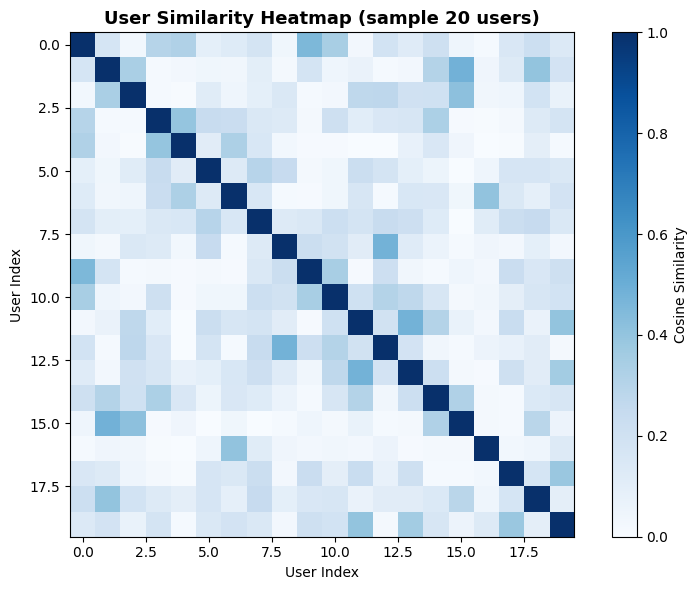


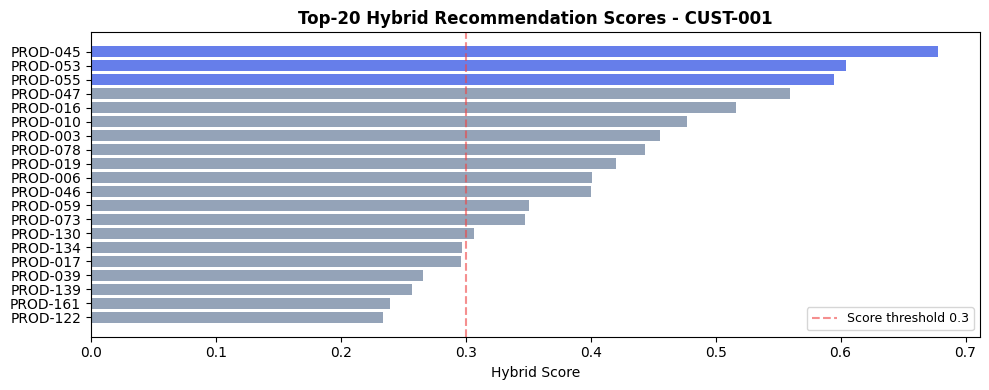


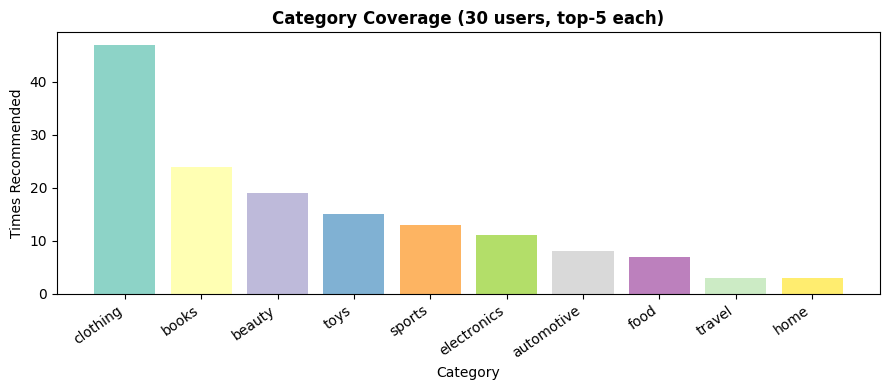

✅ Charts saved to data/charts/


In [12]:
from notebooks.nonagentic.utils import plot_similarity_heatmap, plot_score_distribution, plot_category_coverage
from pathlib import Path

CHARTS = Path("data/charts")
CHARTS.mkdir(exist_ok=True)

plot_similarity_heatmap(MATRIX, _cosine, sample_n=20, charts_dir=CHARTS)
plot_score_distribution(recommend, customer_id="CUST-001", charts_dir=CHARTS)
plot_category_coverage(MATRIX, PROD_MAP, recommend, sample_n=30, charts_dir=CHARTS)
print("✅ Charts saved to data/charts/")


---
## Use Case 9 — Orchestrator Routing to Level 5

**Business scenario**: A business user types a natural language request. The orchestrator automatically classifies it as a `recommendation` intent and routes it to the Level 5 AI — no manual configuration needed.

Examples that route to Level 5:
- *"Recommend a product for customer CUST-001"*
- *"Find similar customers and suggest offers for CUST-042"*
- *"What is the next best offer for this customer?"*
- *"Cross-user recommendation for CUST-099"*

In [14]:
from nonagentic.orchestration.orchestrator import _rule_classify

test_requests = [
    ("Recommend a product for customer CUST-001",              "recommendation"),
    ("Find similar customers and suggest offers for CUST-042", "recommendation"),
    ("What is the next best offer for CUST-099?",              "recommendation"),
    ("Cross-user recommendation for CUST-010",                 "recommendation"),
    ("Suggest products based on purchase history",             "recommendation"),
    ("Show me the profile for CUST-005",                       "informational"),
    ("Segment customers by fraud score",                       "analytical"),
    ("Send a win-back email to CUST-033",                      "action"),
    ("Grow card adoption by 5% this quarter",                  "strategic"),
]

rows, correct = [], 0
for request, expected in test_requests:
    intent, confidence, cid = _rule_classify(request)
    match = intent == expected
    if match: correct += 1
    rows.append({"Request": request[:55] + "..." if len(request) > 55 else request,
                 "Expected": expected, "Classified": intent,
                 "Confidence": f"{confidence:.1%}", "Match": "✅" if match else "❌"})

display_section("🔀 Orchestrator Routing Test")
df_route = pd.DataFrame(rows)
display(df_route.style
    .apply(lambda row: ["background-color:#d1fae5" if row["Match"]=="✅" else "background-color:#fee2e2"]*len(row), axis=1)
    .set_table_styles([{"selector": "th", "props": [("background", "#667eea"), ("color", "white"), ("padding", "8px")]},
                       {"selector": "td", "props": [("padding", "8px")]}])
    .hide(axis="index"))

display_metrics({"Total Tests": len(test_requests), "Correct": correct,
                 "Accuracy": f"{correct/len(test_requests):.1%}"})


Request,Expected,Classified,Confidence,Match
Recommend a product for customer CUST-001,recommendation,recommendation,85.0%,✅
Find similar customers and suggest offers for CUST-042,recommendation,informational,85.0%,❌
What is the next best offer for CUST-099?,recommendation,informational,85.0%,❌
Cross-user recommendation for CUST-010,recommendation,recommendation,85.0%,✅
Suggest products based on purchase history,recommendation,recommendation,85.0%,✅
Show me the profile for CUST-005,informational,informational,85.0%,✅
Segment customers by fraud score,analytical,analytical,85.0%,✅
Send a win-back email to CUST-033,action,informational,85.0%,❌
Grow card adoption by 5% this quarter,strategic,strategic,85.0%,✅


---
## Summary

| Use Case | What the AI does | Key signal |
|---|---|---|
| **1. User-Based** | Aggregate preferences from segment peers | Segment membership |
| **2. Collaborative Filtering** | Find similar users via cosine similarity | Interaction vectors |
| **3. Behaviour-Based** | Score items by clicks, views, purchases | Recency + engagement |
| **4. Hybrid Recommender** | Weighted combination of all signals | 0.4+0.3+0.2+0.1 formula |
| **5. Cold Start** | Segment-level fallback for new users | Popularity + segment |
| **6. Cross-User Segment** | Aggregate recs across a full segment | Segment-wide patterns |
| **7. Evaluation** | Precision@K, Recall@K, MAP, NDCG | Offline hold-out split |
| **8. Visualisation** | Similarity heatmap, score distribution, category coverage | Charts |
| **9. Orchestrator Routing** | Natural language → Level 5 intent classification | Rule + LLM classifier |

---

### Key business benefits

- **Personalisation at scale** — every customer gets a unique ranked list based on their own signals
- **No cold start dead-ends** — new customers always get relevant fallback recommendations
- **Explainable** — every recommendation includes a human-readable explanation
- **Composable** — Level 3 can act on these recommendations (send email, create offer)
- **Measurable** — built-in evaluation harness ready for A/B testing

---

### What comes next

Level 5 is the **recommendation** layer. To act on its output:

- **Level 3** — send the top recommendation as a personalised notification
- **Level 4** — orchestrate a full recommendation-driven campaign across a segment
- **Level 2** — analyse which recommendation categories drive the highest conversion

---

### Technical notes

**Data sources**:
- `data/customers.json` — 208 customer profiles
- `data/products.json` — 200 products across 10 categories
- `data/interactions.json` — 5000 interactions (view/click/purchase)

**Hybrid weights** (configurable via `RECOMMENDATION_WEIGHTS` env var):
```
collaborative=0.4  behaviour=0.3  content=0.2  popularity=0.1
```

**Charts saved to**: `data/charts/`

**Audit log**: `data/audit.jsonl`